In [253]:
%pip install seaborn
import seaborn as sns

In [254]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [255]:
from sklearn.preprocessing import StandardScaler

In [256]:
df=pd.read_csv("Retail_Dataset_.csv")

In [257]:
print(df.head(10))

   Customer_ID  Annual_spending  Purchase_frequency Income_level  \
0            1            910.0                11.0          NaN   
1            2           5440.0                58.0       Medium   
2            3           5276.0                55.0         High   
3            4           5241.0                28.0       Medium   
4            5           3822.0                25.0          Low   
5            6              NaN                39.0         High   
6            7            516.0                33.0          NaN   
7            8           5384.0                 1.0          Low   
8            9              NaN                57.0       Medium   
9           10           3494.0                27.0       Medium   

  Customer_segment  Avg_order_value  Loyalty_score Region  Gender  
0              NaN              NaN           89.0  North     NaN  
1          Premium            59.16           18.0  North  Female  
2          Premium            97.00            

In [258]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Customer_ID         150 non-null    int64  
 1   Annual_spending     135 non-null    float64
 2   Purchase_frequency  135 non-null    float64
 3   Income_level        135 non-null    object 
 4   Customer_segment    135 non-null    object 
 5   Avg_order_value     135 non-null    float64
 6   Loyalty_score       135 non-null    float64
 7   Region              135 non-null    object 
 8   Gender              135 non-null    object 
dtypes: float64(4), int64(1), object(4)
memory usage: 8.3+ KB


In [259]:
df.describe()

,Customer_ID,Annual_spending,Purchase_frequency,Avg_order_value,Loyalty_score
count,150.000000,135.000000,135.000000,135.000000,135.000000
mean,75.500000,2814.251852,30.503704,72.145481,51.814815
std,43.445368,1589.730282,18.173243,18.558983,27.775267
min,1.000000,84.000000,1.000000,40.680000,5.000000
25%,38.250000,1531.000000,14.000000,57.365000,29.000000
50%,75.500000,2779.000000,32.000000,73.110000,53.000000
75%,112.750000,4115.500000,48.000000,88.800000,77.500000
max,150.000000,5443.000000,59.000000,99.980000,99.000000


In [260]:
df.isnull().sum()

Customer_ID            0
Annual_spending       15
Purchase_frequency    15
Income_level          15
Customer_segment      15
Avg_order_value       15
Loyalty_score         15
Region                15
Gender                15
dtype: int64

In [261]:
Q1 = df[num_cols].quantile(0.25)
Q3 = df[num_cols].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_iqr = df[((df[num_cols] < lower_bound) | (df[num_cols] > upper_bound)).any(axis=1)]

print(f"Number of outliers detected : {len(outliers_iqr)}")


Number of outliers detected : 0


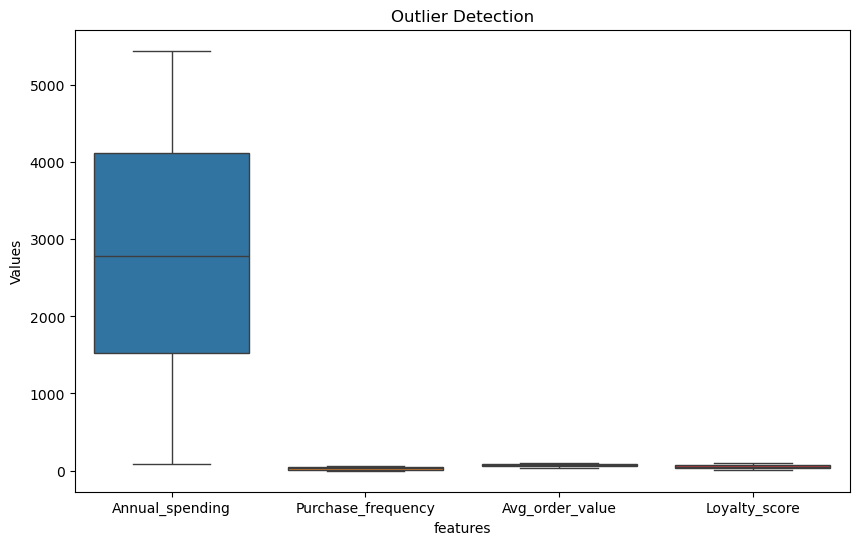

In [262]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df[num_cols])
plt.title('Outlier Detection')
plt.ylabel('Values')
plt.xlabel('features')
plt.show()

In [263]:
num_cols = ['Annual_spending', 'Purchase_frequency', 'Avg_order_value', 'Loyalty_score']
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())
print(df[col])

0      89.0
1      18.0
2      53.0
3      79.0
4      55.0
       ... 
145    68.0
146    53.0
147    60.0
148    63.0
149    74.0
Name: Loyalty_score, Length: 150, dtype: float64


In [264]:
cat_cols = ['Income_level', 'Customer_segment', 'Region', 'Gender']
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])
print(df[col])   

0        Male
1      Female
2        Male
3        Male
4      Female
        ...  
145      Male
146      Male
147    Female
148    Female
149    Female
Name: Gender, Length: 150, dtype: object


In [265]:
df.isnull().sum()

Customer_ID           0
Annual_spending       0
Purchase_frequency    0
Income_level          0
Customer_segment      0
Avg_order_value       0
Loyalty_score         0
Region                0
Gender                0
dtype: int64

In [266]:
df["Income_level"].unique()

array(['Medium', 'High', 'Low'], dtype=object)

In [267]:
df["Region"].unique()

array(['North', 'South', 'East', 'West'], dtype=object)

In [268]:
df["Gender"].unique()

array(['Male', 'Female'], dtype=object)

In [269]:
df["Customer_segment"].unique()

array(['Budget', 'Premium', 'Regular'], dtype=object)

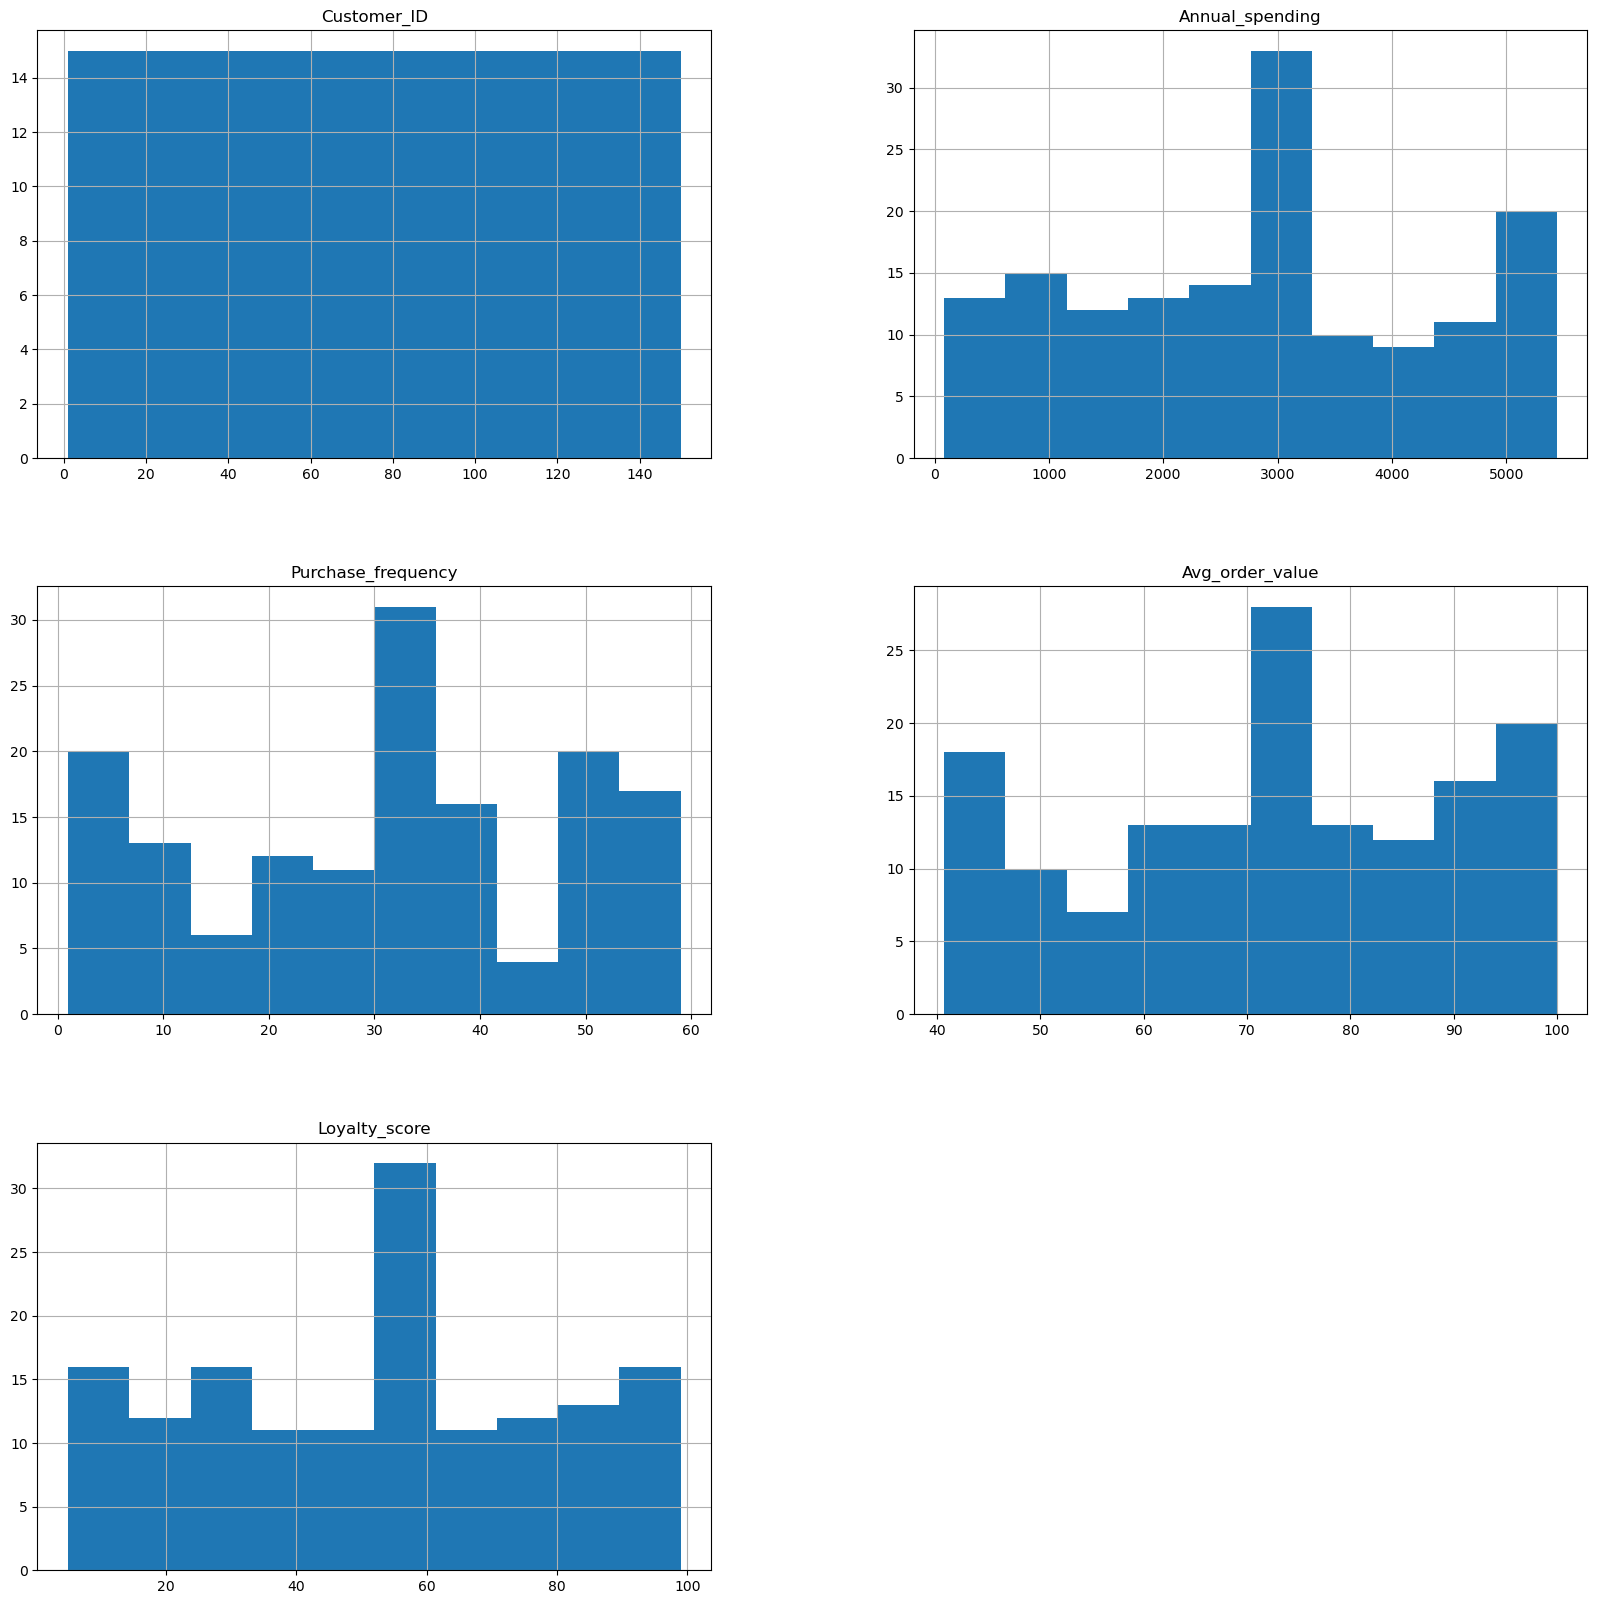

In [270]:
p=df.hist(figsize=(20,20))

In [271]:
print(df.columns)

Index(['Customer_ID', 'Annual_spending', 'Purchase_frequency', 'Income_level',
       'Customer_segment', 'Avg_order_value', 'Loyalty_score', 'Region',
       'Gender'],
      dtype='object')


In [272]:
scaler = StandardScaler()
num_cols = ['Annual_spending', 'Purchase_frequency', 'Avg_order_value', 'Loyalty_score']
df[num_cols] = scaler.fit_transform(df[num_cols])
print(df.head(10))

   Customer_ID  Annual_spending  Purchase_frequency Income_level  \
0            1        -1.264966           -1.143796       Medium   
1            2         1.749826            1.591538       Medium   
2            3         1.640681            1.416942         High   
3            4         1.617388           -0.154420       Medium   
4            5         0.673019           -0.329016          Low   
5            6        -0.021115            0.485764         High   
6            7        -1.527179            0.136573       Medium   
7            8         1.712557           -1.725782          Low   
8            9        -0.021115            1.533339       Medium   
9           10         0.454730           -0.212619       Medium   

  Customer_segment  Avg_order_value  Loyalty_score Region  Gender  
0           Budget         0.049480       1.411818  North    Male  
1          Premium        -0.745679      -1.292474  North  Female  
2          Premium         1.411226       0.040